In [46]:
# Load libraries

import os
import pandas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
import sklearn.model_selection
import shutil

# import my extended pySuStaIn model
from apoe4_sustain import ZscoreSustain_APOE4
# import simulation function
from genetics_simulation_utils import simulate_apoe_sustain_dataset #genetics_simulation,


1. Simulate biomarkers using zscore SuStaIn model and a categorical variable: APOE carrier status based on fixed genetic probabilities

In [47]:
# define hyper-parameters of simulation
# Configure dataset dimensions
M_patients = 1000
N_biomarkers = 5

In [48]:
# N_subtypes = 1
# gt_fractions = np.array([1.0])
# W_true_target = np.array([
#     [1/3, 1/3, 1/3],  # Subtype 0: High Category 0 anchor[1/3, 1/3, 1/3]   # Subtype 1: High Category 2 anchor
# ])


In [49]:
N_subtypes = 2
gt_fractions = np.array([0.45, 0.55])


#Define the explicit ground-truth genetic profiles for this sandbox run
W_true_target = np.array([
    [0.80, 0.15, 0.05],  # Subtype 0: High Category 0 anchor
    [0.10, 0.30, 0.60]   # Subtype 1: High Category 2 anchor
])

# # #Uniform case
# # W_true_target = np.array([
# #     [1/3, 1/3, 1/3],  # Subtype 0: High Category 0 anchor
# #     [1/3, 1/3, 1/3]   # Subtype 1: High Category 2 anchor
# # ])


In [50]:
N_subtypes = 3
W_true_target = np.array([
    [0.80, 0.15, 0.05],  # Subtype 0: High Category 0 anchor
    [0.10, 0.30, 0.60],
    [0.40, 0.40,0.20] ,  # Subtype 1: High Category 2 anchor
])
gt_fractions = np.array([0.60, 0.30, 0.10])

In [51]:

# Generate the dataset in-memory
df, Z_vals, Z_max, gt_ordering, gt_fractions, W_true = simulate_apoe_sustain_dataset(N = N_biomarkers,              
                                                                            M = M_patients,            # number of observations (e.g. subjects)
                                                                            N_S_gt = N_subtypes,         # number of ground truth subtypes
                                                                            gt_f = gt_fractions,         # could also be None
                                                                            W_true = W_true_target,      # genetic_weights
                                                                            genetic_signal_strength = None # could be 'uniform', 'moderate' or 'strong
                                                                            )
df

Generator(PCG64)


,Biomarker 0,Biomarker 1,Biomarker 2,Biomarker 3,Biomarker 4,gt_subtypes,gt_stages,apoe_status
0,0.000000,0.000000,0.000000,0.000000,0.000,0,0.0,1
1,0.000000,0.000000,0.000000,0.000000,0.000,0,0.0,2
2,0.000000,0.000000,0.000000,0.000000,0.000,0,0.0,0
3,0.000000,0.000000,0.000000,0.000000,0.000,0,0.0,2
4,0.000000,0.000000,0.000000,0.000000,0.000,0,0.0,2
...,...,...,...,...,...,...,...,...
995,2.666667,1.375000,2.200000,0.666667,1.000,1,6.0,0
996,2.000000,0.307692,1.142857,1.500000,0.800,3,4.0,2
997,0.333333,1.500000,0.600000,2.000000,0.375,2,3.0,2
998,0.333333,1.500000,0.600000,2.000000,0.375,2,3.0,2


In [52]:
# # Generate the dataset in-memory
# old function I no longer use
# df, Z_vals, Z_max, gt_ordering, W_true = genetics_simulation(
#     N=N_biomarkers, 
#     M=M_patients, 
#     N_S_gt=N_subtypes, 
#     gt_fractions=gt_fractions, 
#     W_true=W_true_target, 
#     use_midpoints=False, # Set to True if you want to test your supervisor's midpoint variant
#     save=False
# )

# df

In [53]:
# Extract raw arrays for the model execution
BiomarkerNames = [f'Biomarker {i}' for i in range(N_biomarkers)]
X_data = df[BiomarkerNames].values
y_genetics = df['apoe_status'].values

print(f"Generated data matrix shape: {X_data.shape}")
print(f"Generated genetic vector shape: {y_genetics.shape}")

Generated data matrix shape: (1000, 5)
Generated genetic vector shape: (1000,)


In [54]:
N_startpoints = 15
N_S_max = N_subtypes
N_iterations_MCMC = int(1e4)
#output_folder = os.path.join(os.getcwd(), 'MRI_Sustain_5features_all')



In [55]:
dataset_name = 'simulated_data_genetics_model'
output_folder = os.path.join(os.getcwd(), dataset_name)
sustain_input = ZscoreSustain_APOE4(X_data,
                                Z_vals,
                                Z_max,
                                BiomarkerNames,
                                N_startpoints,
                                N_S_max, 
                                N_iterations_MCMC, 
                                output_folder, 
                                dataset_name, 
                                False,
                                apoe4_status = y_genetics,
                                #apoe4_status = gender_status_array,
                                apoe_flag = True, 
                                em_loop_type = 'alternating' # or combined ; depending on whether I want to optimise sequences and weights in separate EM or together
                                )

1000 patients initially
 -> Detected 3 unique genetic categories: [0 1 2]
1000 patients with non null apoe4 carrier status
 -> [Genetics Setup] Global cohort background frequencies calculated: [0.54  0.213 0.247]
Running genetic weighted SuStaIn 


Run SuStaIn 

In [56]:
# delete previous pickle files
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

In [57]:
# make the output directory if it's not already created
if not os.path.isdir(output_folder):
    os.mkdir(output_folder)

In [58]:

samples_sequence,     \
ml_f_EM,            \
ml_subtype,         \
prob_ml_subtype,    \
ml_stage,           \
prob_ml_stage,      \
prob_subtype_stage,         = sustain_input.run_sustain_algorithm()


Failed to find pickle file: /Users/mihaelacroitor/apoe4_informed/simulated_data_genetics_model/pickle_files/simulated_data_genetics_model_subtype0.pickle. Running SuStaIn model for 0 subtype.
Finding ML solution to 1 cluster problem
Genetic weight estimation converged at iteration 1
EM converged in 3 iterations
Genetic weight estimation converged at iteration 1
EM converged in 3 iterations
Genetic weight estimation converged at iteration 1
EM converged in 4 iterations
Genetic weight estimation converged at iteration 1
EM converged in 5 iterations
Genetic weight estimation converged at iteration 1
EM converged in 4 iterations
Genetic weight estimation converged at iteration 1
EM converged in 3 iterations
Genetic weight estimation converged at iteration 1
EM converged in 3 iterations
Genetic weight estimation converged at iteration 1
EM converged in 4 iterations
Genetic weight estimation converged at iteration 1
EM converged in 2 iterations
Genetic weight estimation converged at iteratio

MCMC Iteration: 100%|██████████| 10000/10000 [00:05<00:00, 1924.96it/s]



   FINAL MODEL SUBTYPE COHORT FRACTIONS
 -> Subtype 1 Cohort Size: 100.00% of dataset

   SUSTAIN GENETIC PRIOR PROFILE (EM MAX LIKELIHOOD)
 -> COHORT BACKGROUND BASELINE : [Cat_0: 0.5400, Cat_1: 0.2130, Cat_2: 0.2470]
------------------------------------------------------------
 -> Subtype 1 Profile Prior : [Cat_0: 0.5400, Cat_1: 0.2130, Cat_2: 0.2470]

Failed to find pickle file: /Users/mihaelacroitor/apoe4_informed/simulated_data_genetics_model/pickle_files/simulated_data_genetics_model_subtype1.pickle. Running SuStaIn model for 1 subtype.
Splitting cluster 1 of 1
Reindexing
 + Resolving 2 cluster problem
Genetic weight estimation converged at iteration 1
EM converged in 4 iterations
Genetic weight estimation converged at iteration 1
EM converged in 3 iterations
Genetic weight estimation converged at iteration 8
EM converged in 9 iterations
Genetic weight estimation converged at iteration 1
EM converged in 3 iterations
Genetic weight estimation converged at iteration 1
EM converged

MCMC Iteration: 100%|██████████| 10000/10000 [00:14<00:00, 700.87it/s]



   FINAL MODEL SUBTYPE COHORT FRACTIONS
 -> Subtype 1 Cohort Size: 30.97% of dataset
 -> Subtype 2 Cohort Size: 69.03% of dataset

   SUSTAIN GENETIC PRIOR PROFILE (EM MAX LIKELIHOOD)
 -> COHORT BACKGROUND BASELINE : [Cat_0: 0.5400, Cat_1: 0.2130, Cat_2: 0.2470]
------------------------------------------------------------
 -> Subtype 1 Profile Prior : [Cat_0: 0.0387, Cat_1: 0.3030, Cat_2: 0.6583]
 -> Subtype 2 Profile Prior : [Cat_0: 0.7649, Cat_1: 0.1726, Cat_2: 0.0624]

Failed to find pickle file: /Users/mihaelacroitor/apoe4_informed/simulated_data_genetics_model/pickle_files/simulated_data_genetics_model_subtype2.pickle. Running SuStaIn model for 2 subtype.
Splitting cluster 1 of 2
Reindexing
 + Resolving 2 cluster problem
Genetic weight estimation converged at iteration 1
EM converged in 4 iterations
Genetic weight estimation converged at iteration 1
EM converged in 3 iterations
Genetic weight estimation converged at iteration 2
EM converged in 3 iterations
Genetic weight estimati

MCMC Iteration: 100%|██████████| 10000/10000 [00:21<00:00, 467.12it/s]



   FINAL MODEL SUBTYPE COHORT FRACTIONS
 -> Subtype 1 Cohort Size: 31.26% of dataset
 -> Subtype 2 Cohort Size: 17.43% of dataset
 -> Subtype 3 Cohort Size: 51.32% of dataset

   SUSTAIN GENETIC PRIOR PROFILE (EM MAX LIKELIHOOD)
 -> COHORT BACKGROUND BASELINE : [Cat_0: 0.5400, Cat_1: 0.2130, Cat_2: 0.2470]
------------------------------------------------------------
 -> Subtype 1 Profile Prior : [Cat_0: 0.0405, Cat_1: 0.3031, Cat_2: 0.6564]
 -> Subtype 2 Profile Prior : [Cat_0: 0.1184, Cat_1: 0.6367, Cat_2: 0.2450]
 -> Subtype 3 Profile Prior : [Cat_0: 0.9838, Cat_1: 0.0154, Cat_2: 0.0008]



### Proof 1 Does the model recover correct params?

## Does the EM converge to max likelihood?

In [59]:
s = N_subtypes - 1
pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
pk = pandas.read_pickle(pickle_filename_s)
ml_likelihood_mat_EM = pk["ml_likelihood_mat_EM"]

ml_genetic_weights_EM = pk["ml_genetic_weights_EM"]
ml_sequence_EM = pk["ml_sequence_EM"]
em_likelihood_histories = pk["em_likelihood_histories"]

In [60]:
em_likelihood_histories

array([[-7801.73487191, -7767.93674682, -7756.11143305, ...,
        -7781.14599311, -7810.6073531 , -7798.50943974],
       [-7752.42159103, -7740.218215  , -7737.42223887, ...,
        -7746.73285772, -7744.63994329, -7745.07915663],
       [-7745.27335399, -7736.05746909, -7734.39624912, ...,
        -7742.56031215, -7735.71721249, -7737.12828107],
       ...,
       [-7735.13979449,            nan,            nan, ...,
        -7733.99213534,            nan,            nan],
       [-7735.11826078,            nan,            nan, ...,
        -7733.98155179,            nan,            nan],
       [-7735.09718924,            nan,            nan, ...,
        -7733.97144074,            nan,            nan]], shape=(100, 15))

In [82]:
em_likelihood_histories[:,10]

array([-7812.37123885, -7752.66663918, -7747.95534725, -7747.36285807,
       -7747.19187912, -7747.10418321, -7747.0393048 , -7746.9810994 ,
       -7746.92471611, -7746.86860225, -7746.81225632, -7746.75552908,
       -7746.69839219, -7746.64085897, -7746.58295703, -7746.52471883,
       -7746.46617843, -7746.40737044, -7746.34832958, -7746.28909058,
       -7746.22968809, -7746.17015659, -7746.11053037, -7746.05084343,
       -7745.99112946, -7745.93142177, -7745.87175326, -7745.81215632,
       -7745.75266283, -7745.69330409, -7745.63411079, -7745.57511295,
       -7745.5163399 , -7745.45782026, -7745.39958185, -7745.34165172,
       -7745.2840561 , -7745.22682037, -7745.16996906, -7745.11352578,
       -7745.05751328, -7745.00195338, -7744.94686696, -7744.89227399,
       -7744.83819349, -7744.78464352, -7744.73164121, -7744.67920274,
       -7744.62734335, -7744.5760773 , -7744.52541796, -7744.47537774,
       -7744.42596815, -7744.37719976, -7744.32908225, -7744.28162444,
      

In [61]:
# calculate actual max likelihood from simulated parameters
sustainData = sustain_input._AbstractSustain__sustainData
true_max_lik,_ ,_, _, _ = sustain_input._calculate_likelihood(sustainData, gt_ordering,gt_fractions, W_true)
print('True max',true_max_lik)

# find max lik for each startpoint
max_lik_startpoint = np.nanmax(em_likelihood_histories, axis = 0)
print('Max lik for every iter',max_lik_startpoint)


converged_to_true_lik = max_lik_startpoint >= true_max_lik
print(converged_to_true_lik)
print(converged_to_true_lik.sum())

True max -7742.512467310317
Max lik for every iter [-7735.09718924 -7731.4384146  -7728.33068303 -7728.20658614
 -7734.40389976 -7728.32297683 -7728.2716083  -7730.02060762
 -7728.24945338 -7734.87058493 -7742.8540422  -7734.57201106
 -7733.97144074 -7731.92533399 -7727.96198794]
[ True  True  True  True  True  True  True  True  True  True False  True
  True  True  True]
14


In [ ]:
# Find avg iterations until convergence across startpoints (all and winning ones)

valid_mask = ~np.isnan(em_likelihood_histories)

# Sum vertically along axis=0 to get an array of 15 integer lengths instantly
iteration_counts_all = np.sum(valid_mask, axis=0)
a_avg_iterations_all = np.mean(iteration_counts_all)


# only for winning trials (where lik reached maximum true_max)
if np.any(converged_to_true_lik):
    # Mask the iteration counts array directly using the boolean success vector
    iteration_counts_win = iteration_counts_all[converged_to_true_lik]
    a_avg_iterations_win = np.mean(iteration_counts_win)
else:
    a_avg_iterations_win = np.nan

# =========================================================================
# DIAGNOSTIC PRINTS
# =========================================================================
print(f"Avg iterations it took to converge across all startingpoints : {a_avg_iterations_all:.1f} iterations ")
print(f"Avg iterations it took to converge across winning startingpoints: {a_avg_iterations_win if np.isnan(a_avg_iterations_win) else f'{a_avg_iterations_win:.1f}'} iterations")

Avg iterations it took to converge across all startingpoints : 85.5 iterations 
Avg iterations it took to converge across winning startingpoints: 84.5 iterations


In [62]:
# compare estimated vs true params
print("True seq", gt_ordering)
print("Estimated seq", ml_sequence_EM)
print("Estimated fractions",ml_f_EM)
print("True genetic weights",W_true_target)
print("Estimated genetics",ml_genetic_weights_EM)

True seq [[ 0.  5.  1.  2.  7.  4.  9. 10.  3. 12.  6. 14.  8. 13. 11.]
 [ 3.  1.  8.  6.  2. 11.  7.  4.  0.  9. 12. 13.  5. 10. 14.]
 [ 0.  3.  2.  5.  4.  8. 10. 13.  9.  7. 14. 12.  1.  6. 11.]]
Estimated seq [[ 3.  1.  8.  6.  2. 11.  7.  4.  0.  9. 12. 13.  5. 10. 14.]
 [ 0.  2.  5.  1.  4.  3.  7. 10.  9.  8. 12. 14.  6. 13. 11.]
 [ 0.  5.  2.  1.  4.  7.  3.  9. 10. 12.  6. 14.  8. 13. 11.]]
Estimated fractions [[0.31256083 0.31256083 0.31256083 ... 0.31631881 0.31631881 0.31631881]
 [0.1742805  0.1742805  0.1742805  ... 0.17020314 0.17020314 0.17020314]
 [0.51315867 0.51315867 0.51315867 ... 0.51347805 0.51347805 0.51347805]]
True genetic weights [[0.8  0.15 0.05]
 [0.1  0.3  0.6 ]
 [0.4  0.4  0.2 ]]
Estimated genetics [[4.04543081e-02 3.03096690e-01 6.56449002e-01]
 [1.18390755e-01 6.36654908e-01 2.44954337e-01]
 [9.83824755e-01 1.54234134e-02 7.51831727e-04]]


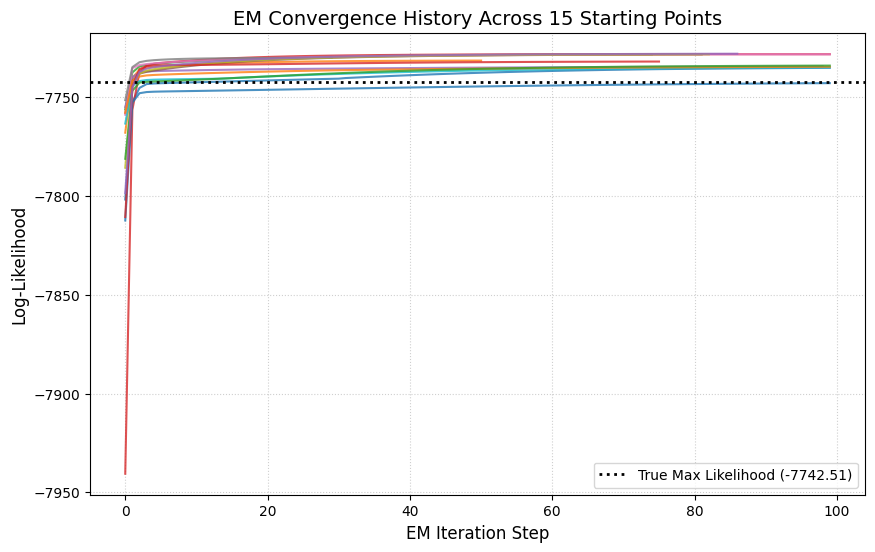

In [81]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Set up the figure size
plt.figure(figsize=(10, 6))

# 2. Plot the array directly
# Matplotlib plots each column (startpoint) as a separate colored line
plt.plot(em_likelihood_histories, linewidth=1.5, alpha=0.8)

# 3. Add your ground-truth maximum likelihood as a horizontal dotted line
# 'ls=":"' makes it dotted, 'color="black"' ensures high contrast, 'zorder=5' keeps it on top
plt.axhline(y=true_max_lik, color="black", linestyle=":", linewidth=2, label=f"True Max Likelihood ({true_max_lik:.2f})")


# 4. Add styling and descriptive labels
plt.xlabel("EM Iteration Step", fontsize=12)
plt.ylabel("Log-Likelihood", fontsize=12)
plt.title(f"EM Convergence History Across {em_likelihood_histories.shape[1]} Starting Points", fontsize=14)

plt.legend()
# 4. Clean up the grid presentation
plt.grid(True, linestyle=":", alpha=0.6)

# 5. Show the plot
plt.show()

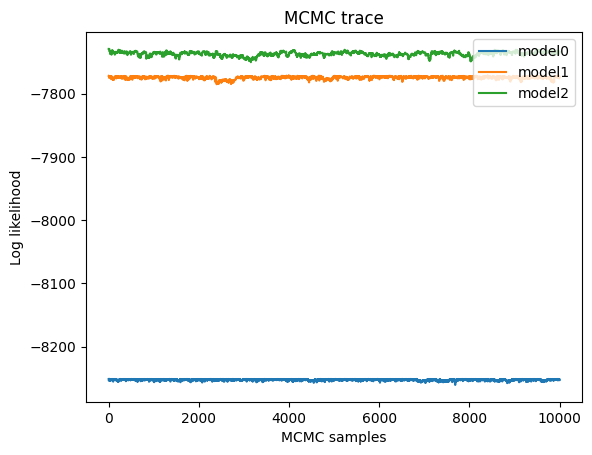

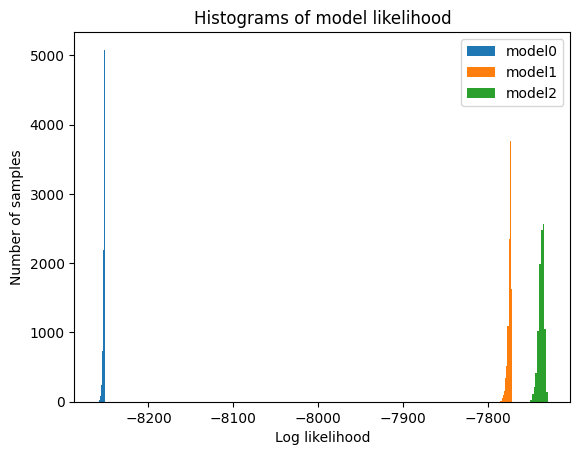

In [23]:
# for each subtype model
for s in range(N_S_max):
    # load pickle file (SuStaIn output) and get the sample log likelihood values
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    samples_likelihood = pk["samples_likelihood"]
    
    # plot the values as a line plot
    fig0 = plt.figure(0)
    plt.plot(range(N_iterations_MCMC), samples_likelihood, label="model" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('MCMC samples')
    plt.ylabel('Log likelihood')
    plt.title('MCMC trace')
    
    # plot the values as a histogramp plot
    fig1 = plt.figure(1)
    plt.hist(samples_likelihood, label="model" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('Log likelihood')  
    plt.ylabel('Number of samples')  
    plt.title('Histograms of model likelihood')
fig0.savefig(output_folder+'/mcmc_trace.png')
fig1.savefig(output_folder+'/mcmc_histogram.png')


0
[1.]
[0]
1
[0.33198495 0.66801505]
[0 1]
2
[0.07289286 0.6194926  0.30761455]
[0 2 1]


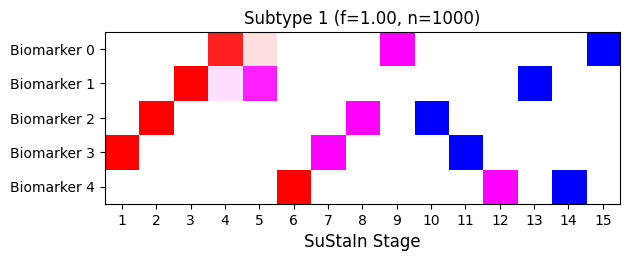

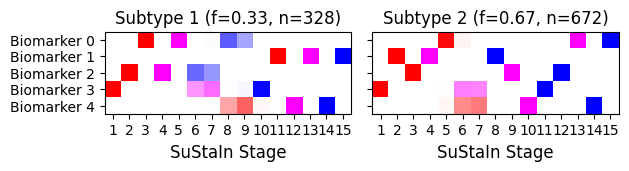

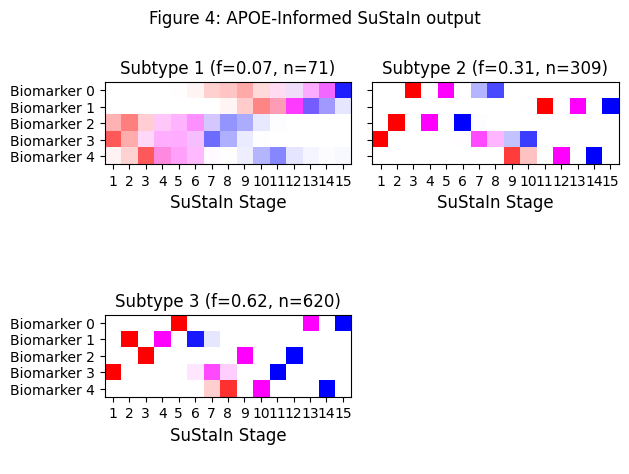

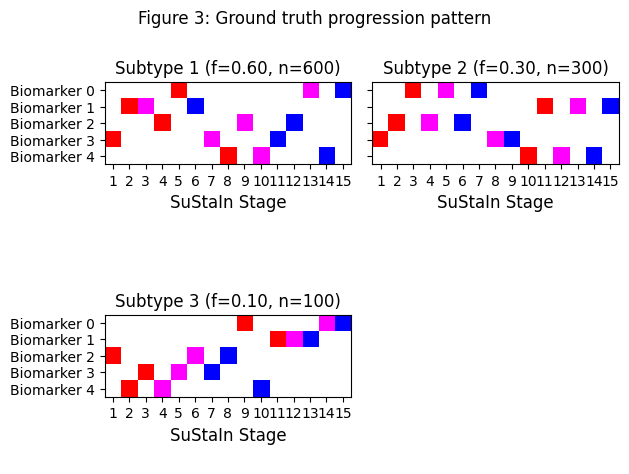

In [24]:

use_outlier = False
for s in range(N_S_max):
    print(s)
    #s = 1 # 1 split = 2 subtypes
    M = len(X_data) 

    # get the sample sequences and f
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    samples_sequence = pk["samples_sequence"]
    samples_f = pk["samples_f"]
    ml_f_EM = pk["ml_f_EM"]
    print(ml_f_EM)
    if use_outlier:
        subtype_order = np.argsort(ml_f_EM[:-1])
    else:
        subtype_order = np.argsort(ml_f_EM)
    print(subtype_order)
    # use this information to plot the positional variance diagrams
    tmp=ZscoreSustain_APOE4._plot_sustain_model(sustain_input,samples_sequence,samples_f,M,subtype_order=subtype_order,biomarker_labels=BiomarkerNames)
    plt.savefig(output_folder + f"/pos_var_diagrams{s}.png")
_ = plt.suptitle('Figure 4: APOE-Informed SuStaIn output')

# Output a figure showing the ground truth
gt_sequence = gt_ordering
gt_f        = gt_fractions
temp_gt_sequence = np.tile(np.reshape(gt_sequence,(gt_sequence.shape[0],gt_sequence.shape[1],1)),100)
temp_gt_f = np.asarray(gt_f).reshape(len(gt_f),1)
dynamic_gt_order = np.arange(gt_sequence.shape[0])
ZscoreSustain_APOE4._plot_sustain_model(sustain_input,temp_gt_sequence,temp_gt_f,M,subtype_order=dynamic_gt_order)
_ = plt.suptitle('Figure 3: Ground truth progression pattern')


Run baseline SuStaIn to compare

In [25]:
dataset_name = 'simulated_data_baseline_SuStaIn'
output_folder = os.path.join(os.getcwd(), dataset_name)
sustain_bl = ZscoreSustain_APOE4(X_data,
                                Z_vals,
                                Z_max,
                                BiomarkerNames,
                                N_startpoints,
                                N_subtypes, 
                                N_iterations_MCMC, 
                                output_folder, 
                                dataset_name, 
                                False,
                                apoe4_status = y_genetics,
                                #apoe4_status = gender_status_array,
                                apoe_flag = False)

Running baseline SuStain


In [26]:
# delete previous pickle files
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

In [27]:
# make the output directory if it's not already created
if not os.path.isdir(output_folder):
    os.mkdir(output_folder)

In [28]:
ml_sequence_EM,     \
ml_f_EM,            \
ml_subtype,         \
prob_ml_subtype,    \
ml_stage,           \
prob_ml_stage,      \
prob_subtype_stage,         = sustain_bl.run_sustain_algorithm()

Failed to find pickle file: /Users/mihaelacroitor/apoe4_informed/simulated_data_baseline_SuStaIn/pickle_files/simulated_data_baseline_SuStaIn_subtype0.pickle. Running SuStaIn model for 0 subtype.
Finding ML solution to 1 cluster problem
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 5 iterations
EM converged in 3 iterations
EM converged in 4 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 4 iterations
EM converged in 3 iterations
EM converged in 4 iterations
EM converged in 3 iterations
EM converged in 4 iterations
EM converged in 4 iterations
EM converged in 4 iterations
Overall ML likelihood is -7251.186307207156


MCMC Iteration: 100%|██████████| 10000/10000 [00:04<00:00, 2059.55it/s]



   FINAL MODEL SUBTYPE COHORT FRACTIONS
 -> Subtype 1 Cohort Size: 100.00% of dataset

Failed to find pickle file: /Users/mihaelacroitor/apoe4_informed/simulated_data_baseline_SuStaIn/pickle_files/simulated_data_baseline_SuStaIn_subtype1.pickle. Running SuStaIn model for 1 subtype.
Splitting cluster 1 of 1
Reindexing
 + Resolving 2 cluster problem
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 4 iterations
EM converged in 4 iterations
EM converged in 3 iterations
EM converged in 5 iterations
EM converged in 4 iterations
EM converged in 3 iterations
EM converged in 6 iterations
EM converged in 3 iterations
EM converged in 4 iterations
EM converged in 5 iterations
EM converged in 4 iterations
EM converged in 3 iterations
EM converged in 4 iterations
EM converged in 4 iterations
EM converged in 4 iterations
EM converged in 5 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 5 iterations
EM converged in 4 iterations
EM converge

MCMC Iteration: 100%|██████████| 10000/10000 [00:10<00:00, 911.52it/s]



   FINAL MODEL SUBTYPE COHORT FRACTIONS
 -> Subtype 1 Cohort Size: 33.33% of dataset
 -> Subtype 2 Cohort Size: 66.67% of dataset

Failed to find pickle file: /Users/mihaelacroitor/apoe4_informed/simulated_data_baseline_SuStaIn/pickle_files/simulated_data_baseline_SuStaIn_subtype2.pickle. Running SuStaIn model for 2 subtype.
Splitting cluster 1 of 2
Reindexing
 + Resolving 2 cluster problem
EM converged in 2 iterations
EM converged in 5 iterations
EM converged in 2 iterations
EM converged in 4 iterations
EM converged in 3 iterations
EM converged in 2 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 2 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 4 iterations
EM converged in 8 iterations
EM converged in 4 iterations
EM converged in 3 iterations
EM converged in 1 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 1 iterati

MCMC Iteration: 100%|██████████| 10000/10000 [00:15<00:00, 645.97it/s]



   FINAL MODEL SUBTYPE COHORT FRACTIONS
 -> Subtype 1 Cohort Size: 28.57% of dataset
 -> Subtype 2 Cohort Size: 63.89% of dataset
 -> Subtype 3 Cohort Size: 7.54% of dataset



In [29]:
# calculate actual max likelihood from simulated parameters

sustainData = sustain_bl._AbstractSustain__sustainData

true_max_lik,_ ,_, _, _ = sustain_bl._calculate_likelihood(sustainData, gt_ordering,gt_fractions)

print(true_max_lik)
# see how many startingpoints achieved that

# look at last model (N_S == true)
#s = N_subtypes - 1
s = 0
pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
print(pickle_filename_s)
pk = pandas.read_pickle(pickle_filename_s)
ml_likelihood_mat_EM = pk["ml_likelihood_mat_EM"]

# did any starting points converge?
max_indices = np.where(np.isclose(ml_likelihood_mat_EM, true_max_lik))[0]
occurrence_count = len(max_indices)
print(f" {occurrence_count} starting points converged to true max lik {true_max_lik}")
#print(f"Reached by startpoints:   {max_indices}")

# find max EM lik, and how many times it is reached;
max_val = np.max(ml_likelihood_mat_EM)
max_indices = np.where(np.isclose(ml_likelihood_mat_EM, max_val))[0]
occurrence_count = len(max_indices)
print(f"Maximum Likelihood Value: {max_val} reached by {occurrence_count} startingpoints")
#print(f"Reached by startpoints:   {max_indices}")

ml_sequence_EM = pk["ml_sequence_EM"]
ml_f_EM = pk["ml_f_EM"]
print('ML seq EM', ml_sequence_EM)
print('True simulated seq', gt_ordering)

em_likelihood_histories = pk["em_likelihood_histories"]
print('EM lik hist',em_likelihood_histories)



-6921.433276391361
/Users/mihaelacroitor/apoe4_informed/simulated_data_baseline_SuStaIn/pickle_files/simulated_data_baseline_SuStaIn_subtype0.pickle
 0 starting points converged to true max lik -6921.433276391361
Maximum Likelihood Value: -7251.186307207156 reached by 5 startingpoints
ML seq EM [[ 3.  2.  1.  0.  6.  4.  8.  7.  5. 12. 13.  9. 11. 14. 10.]]
True simulated seq [[ 3.  1.  6.  2.  0. 11.  8.  4.  7.  9. 13. 12.  5. 14. 10.]
 [ 3.  2.  0.  7.  5. 12. 10.  8. 13.  4.  1.  9.  6. 14. 11.]
 [ 2.  4.  3.  9.  8.  7. 13. 12.  0. 14.  1.  6. 11.  5. 10.]]
EM lik hist [[-7308.04162018 -7260.79010444 -7299.86864036 ... -7272.69858163
  -7295.33281528 -7303.86410848]
 [-7251.18630721 -7253.6847334  -7272.69858163 ... -7256.88762207
  -7253.54694698 -7260.79010444]
 [-7251.18630721 -7253.6847334  -7256.88762207 ... -7253.6847334
  -7251.18630721 -7253.6847334 ]
 ...
 [           nan            nan            nan ...            nan
             nan            nan]
 [           nan   

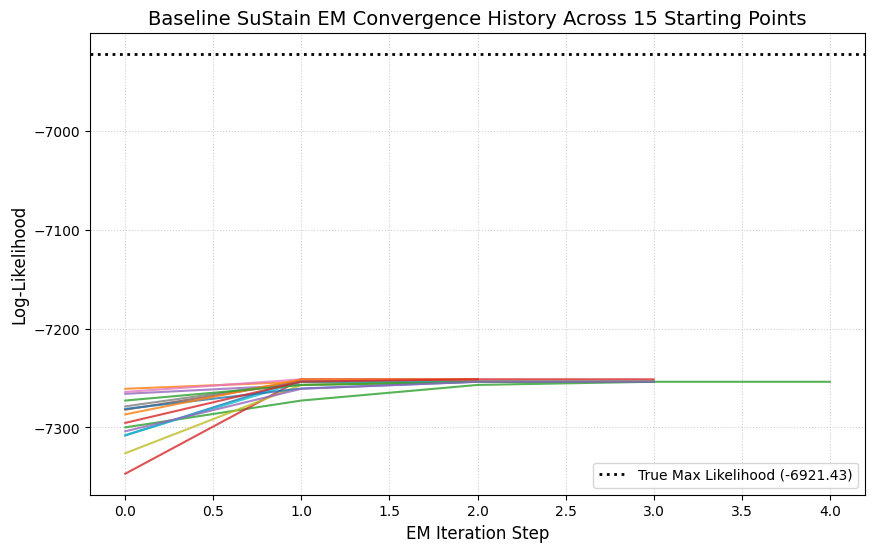

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Set up the figure size
plt.figure(figsize=(10, 6))

# 2. Plot the array directly
# Matplotlib plots each column (startpoint) as a separate colored line
plt.plot(em_likelihood_histories, linewidth=1.5, alpha=0.8)

# 3. Add your ground-truth maximum likelihood as a horizontal dotted line
# 'ls=":"' makes it dotted, 'color="black"' ensures high contrast, 'zorder=5' keeps it on top
plt.axhline(y=true_max_lik, color="black", linestyle=":", linewidth=2, label=f"True Max Likelihood ({true_max_lik:.2f})")


# 4. Add styling and descriptive labels
plt.xlabel("EM Iteration Step", fontsize=12)
plt.ylabel("Log-Likelihood", fontsize=12)
plt.title(f"Baseline SuStain EM Convergence History Across {em_likelihood_histories.shape[1]} Starting Points", fontsize=14)

plt.legend()
# 4. Clean up the grid presentation
plt.grid(True, linestyle=":", alpha=0.6)

# 5. Show the plot
plt.show()

In [31]:
# Extract the active data container
sustainData = sustain_bl._AbstractSustain__sustainData

# Calculate the likelihood using the EXACT sequence and weights the model chose
test_loglike, _, _, _, _ = sustain_bl._calculate_likelihood(
    sustainData, 
    ml_sequence_EM,     # Your optimized sequence
    ml_f_EM            # Your optimized fractions
    #ml_genetic_weights_EM  # Pass the OPTIMIZED weights, not W_true!
)

print(f"Likelihood using Optimized EM Weights: {test_loglike:.2f}")
print(f"Final Plateau Level on your Plot:     {np.max(em_likelihood_histories[:,0])}")

Likelihood using Optimized EM Weights: -7251.19
Final Plateau Level on your Plot:     nan


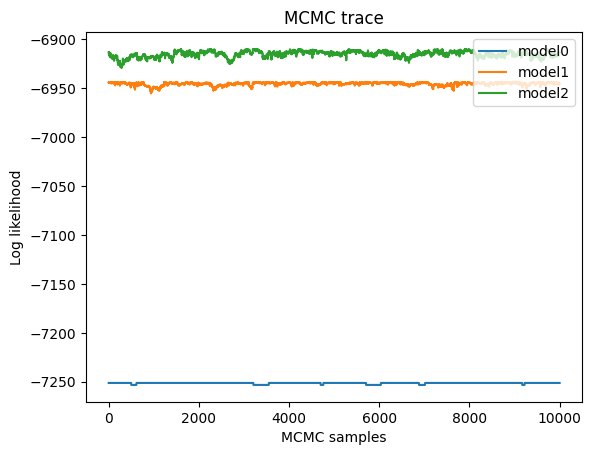

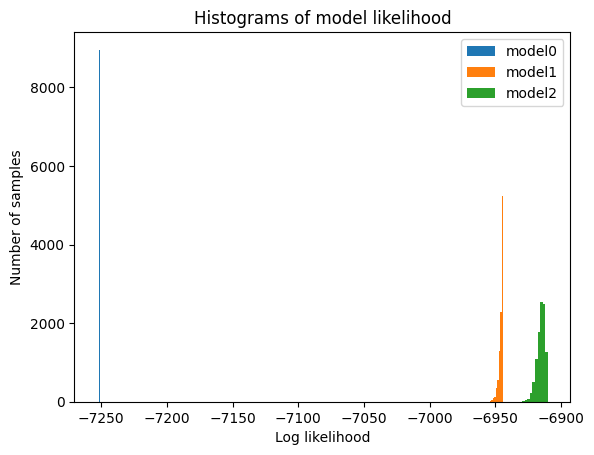

In [32]:
# for each subtype model
for s in range(N_S_max):
    # load pickle file (SuStaIn output) and get the sample log likelihood values
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    samples_likelihood = pk["samples_likelihood"]
    
    # plot the values as a line plot
    fig0 = plt.figure(0)
    plt.plot(range(N_iterations_MCMC), samples_likelihood, label="model" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('MCMC samples')
    plt.ylabel('Log likelihood')
    plt.title('MCMC trace')
    
    # plot the values as a histogramp plot
    fig1 = plt.figure(1)
    plt.hist(samples_likelihood, label="model" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('Log likelihood')  
    plt.ylabel('Number of samples')  
    plt.title('Histograms of model likelihood')
fig0.savefig(output_folder+'/mcmc_trace.png')
fig1.savefig(output_folder+'/mcmc_histogram.png')


0
[1.]
[0]
1
[0.3332912 0.6667088]
[0 1]
2
[0.28566416 0.63893193 0.07540391]
[2 0 1]


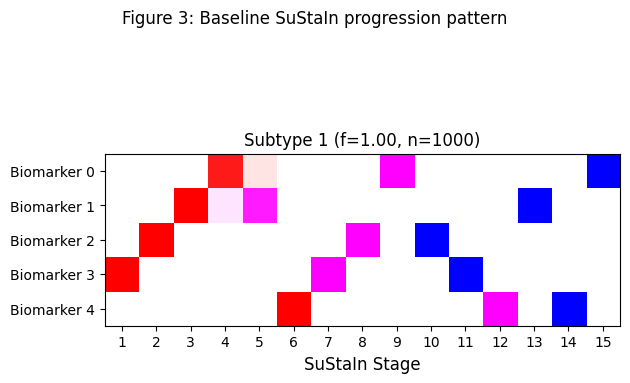

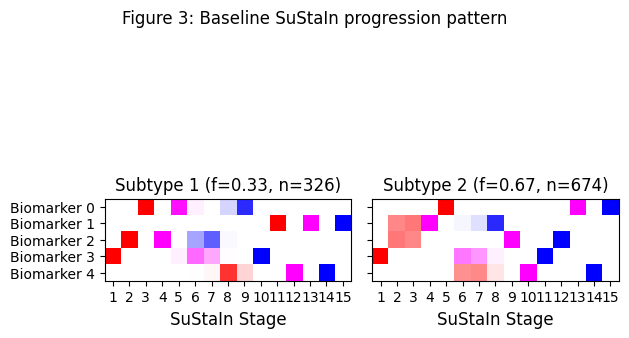

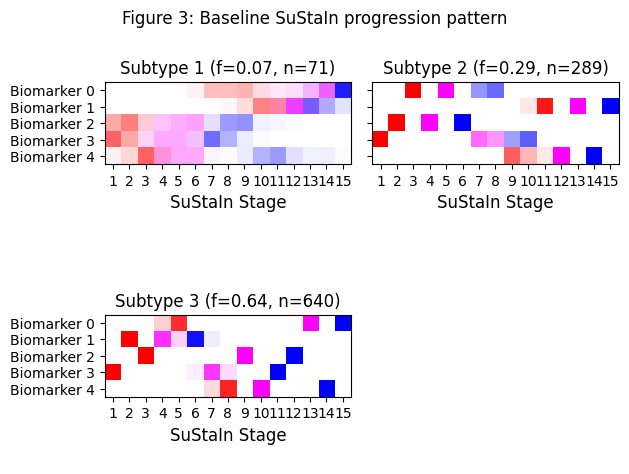

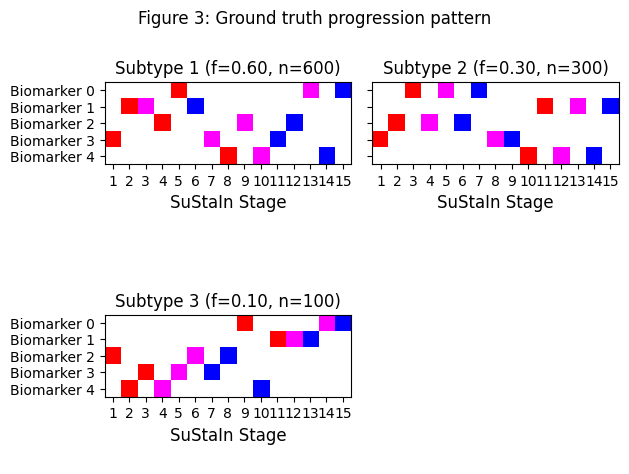

In [33]:
# Let's plot positional variance diagrams to interpret the subtype progressions
use_outlier = False
for s in range(N_S_max):
    print(s)
    #s = 1 # 1 split = 2 subtypes
    M = len(X_data) 

    # get the sample sequences and f
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    samples_sequence = pk["samples_sequence"]
    samples_f = pk["samples_f"]
    ml_f_EM = pk["ml_f_EM"]
    print(ml_f_EM)
    if use_outlier:
        subtype_order = np.argsort(ml_f_EM[:-1])
    else:
        subtype_order = np.argsort(ml_f_EM)
    print(subtype_order)
    # use this information to plot the positional variance diagrams
    tmp=ZscoreSustain_APOE4._plot_sustain_model(sustain_input,samples_sequence,samples_f,M,subtype_order=subtype_order,biomarker_labels=BiomarkerNames)
    plt.savefig(output_folder + f"/pos_var_diagrams{s}.png")
    _ = plt.suptitle('Figure 3: Baseline SuStaIn progression pattern')

# Output a figure showing the ground truth
gt_sequence = gt_ordering
gt_f        = gt_fractions
temp_gt_sequence = np.tile(np.reshape(gt_sequence,(gt_sequence.shape[0],gt_sequence.shape[1],1)),100)
temp_gt_f = np.asarray(gt_f).reshape(len(gt_f),1)
ZscoreSustain_APOE4._plot_sustain_model(sustain_input,temp_gt_sequence,temp_gt_f,M,subtype_order=(0,1,2))
_ = plt.suptitle('Figure 3: Ground truth progression pattern')

In [34]:
print('Estimated seq',ml_sequence_EM)
print('True seq',gt_ordering)

Estimated seq [[ 3.  2.  1.  0.  6.  4.  8.  7.  5. 12. 13.  9. 11. 14. 10.]]
True seq [[ 3.  1.  6.  2.  0. 11.  8.  4.  7.  9. 13. 12.  5. 14. 10.]
 [ 3.  2.  0.  7.  5. 12. 10.  8. 13.  4.  1.  9.  6. 14. 11.]
 [ 2.  4.  3.  9.  8.  7. 13. 12.  0. 14.  1.  6. 11.  5. 10.]]
